In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


In [7]:
df = pd.read_csv("/content/track_point.csv")
df.head()

,row_index,date_time,free_time,track_id,scan_or_track_mode,radar_mode,track_times,lost_times,range_index,azim_index,...,altitude,is_measured,effective_track_size,remaining_lost_times,established_mode,track_quality,speed_3d,target_type,tmp_target_type,measure_or_simulate_flag
0,37557,2025-04-11T08:50:58.853,46265.3412,11667,0,1,1,0,360,68,...,684.031133,1,1,2,0,0.65,15.365417,4,0,0
1,37558,2025-04-11T08:51:00.855,46267.3442,11667,0,1,2,0,355,68,...,677.300016,1,2,3,0,0.66,16.355060,4,0,0
2,37559,2025-04-11T08:51:02.859,46269.3476,11667,0,1,3,0,350,68,...,674.557443,1,3,4,1,0.75,15.098385,4,0,0
3,37569,2025-04-11T08:51:04.847,46271.3346,11667,0,1,4,0,345,67,...,679.262763,1,4,5,1,0.80,43.101824,4,0,0
4,37581,2025-04-11T08:51:06.849,46273.3376,11667,0,1,5,0,339,67,...,676.349425,1,5,6,2,0.85,20.480564,0,0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   row_index                 750 non-null    int64  
 1   date_time                 750 non-null    object 
 2   free_time                 750 non-null    float64
 3   track_id                  750 non-null    int64  
 4   scan_or_track_mode        750 non-null    int64  
 5   radar_mode                750 non-null    int64  
 6   track_times               750 non-null    int64  
 7   lost_times                750 non-null    int64  
 8   range_index               750 non-null    int64  
 9   azim_index                750 non-null    int64  
 10  elev_index                750 non-null    int64  
 11  range                     750 non-null    float64
 12  azim_deg                  750 non-null    float64
 13  elev_deg                  750 non-null    float64
 14  vr        

In [9]:
df.isnull().sum()

,0
row_index,0
date_time,0
free_time,0
track_id,0
scan_or_track_mode,0
radar_mode,0
track_times,0
lost_times,0
range_index,0
azim_index,0


In [10]:
df.describe()

,row_index,free_time,track_id,scan_or_track_mode,radar_mode,track_times,lost_times,range_index,azim_index,elev_index,...,altitude,is_measured,effective_track_size,remaining_lost_times,established_mode,track_quality,speed_3d,target_type,tmp_target_type,measure_or_simulate_flag
count,750.000000,750.000000,750.0,750.0,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,...,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.0,750.0
mean,104206.509333,50748.717582,11667.0,0.0,0.978667,291.920000,0.217333,471.981333,96.640000,7.126667,...,605.081801,0.884000,310.212000,7.396000,1.900000,0.927139,17.236891,1.096000,0.0,0.0
std,212080.958744,12171.195466,0.0,0.0,0.144589,199.359178,0.766082,173.953041,23.049862,0.696133,...,130.922604,0.320439,212.025785,1.649286,0.437709,0.127946,13.143338,0.742643,0.0,0.0
min,37557.000000,46265.341200,11667.0,0.0,0.000000,1.000000,0.000000,23.000000,51.000000,5.000000,...,82.928311,0.000000,1.000000,0.000000,-1.000000,0.312000,1.823550,0.000000,0.0,0.0
25%,40129.500000,46666.450150,11667.0,0.0,1.000000,112.250000,0.000000,405.000000,77.000000,7.000000,...,630.286493,1.000000,116.250000,8.000000,2.000000,0.924508,12.100784,1.000000,0.0,0.0
50%,42816.500000,47054.581600,11667.0,0.0,1.000000,289.500000,0.000000,456.000000,98.000000,7.000000,...,644.465459,1.000000,306.500000,8.000000,2.000000,0.987914,15.184309,1.000000,0.0,0.0
75%,45066.750000,47429.716700,11667.0,0.0,1.000000,466.750000,0.000000,538.000000,113.000000,7.000000,...,663.854792,1.000000,494.750000,8.000000,2.000000,0.989059,19.398767,1.000000,0.0,0.0
max,956492.000000,93616.698150,11667.0,0.0,1.000000,634.000000,8.000000,1361.000000,140.000000,10.000000,...,896.321102,1.000000,683.000000,8.000000,2.000000,0.993939,167.482620,4.000000,0.0,0.0


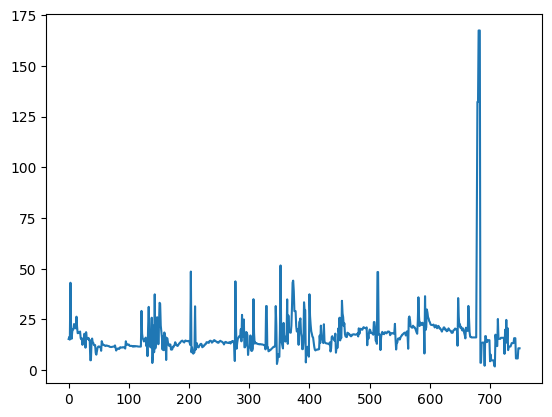

In [11]:
plt.plot(df["speed_3d"])
plt.show()


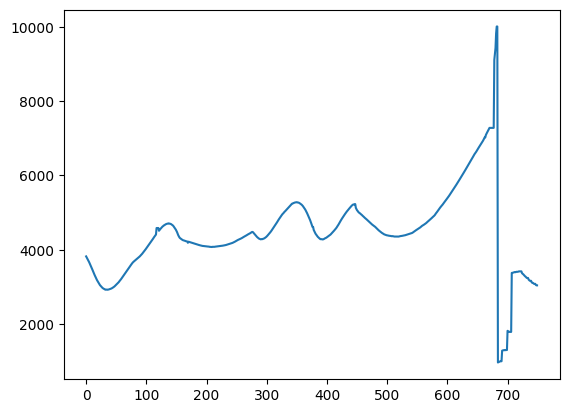

In [12]:
plt.plot(df["range"])
plt.show()

In [13]:
X = df.drop(columns=["latitude", "longitude","date_time"])
y = df[["latitude", "longitude"]]

In [14]:
X.head()

,row_index,free_time,track_id,scan_or_track_mode,radar_mode,track_times,lost_times,range_index,azim_index,elev_index,...,altitude,is_measured,effective_track_size,remaining_lost_times,established_mode,track_quality,speed_3d,target_type,tmp_target_type,measure_or_simulate_flag
0,37557,46265.3412,11667,0,1,1,0,360,68,7,...,684.031133,1,1,2,0,0.65,15.365417,4,0,0
1,37558,46267.3442,11667,0,1,2,0,355,68,7,...,677.300016,1,2,3,0,0.66,16.355060,4,0,0
2,37559,46269.3476,11667,0,1,3,0,350,68,7,...,674.557443,1,3,4,1,0.75,15.098385,4,0,0
3,37569,46271.3346,11667,0,1,4,0,345,67,7,...,679.262763,1,4,5,1,0.80,43.101824,4,0,0
4,37581,46273.3376,11667,0,1,5,0,339,67,7,...,676.349425,1,5,6,2,0.85,20.480564,0,0,0


In [15]:
y.head()

,latitude,longitude
0,17.383625,44.318875
1,17.383738,44.318598
2,17.383968,44.318441
3,17.384668,44.318782
4,17.385023,44.318677


In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=10)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((600, 47), (150, 47), (600, 2), (150, 2))

**Random Forest Regressor**

In [61]:
model = RandomForestRegressor(random_state=10)
model.fit(X, y)


RandomForestRegressor(random_state=10)

In [62]:
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

0.9998716032277205

**XGBoost**

In [65]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [66]:
y_pred_xgb = xgb_model.predict(X_test)
r2_score(y_test, y_pred_xgb)

0.9995800256729126